<a href="https://colab.research.google.com/github/golammoula287/Assignment_1/blob/main/Thesis_DataSet_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle tqdm


In [ ]:
from google.colab import files
files.upload()


In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import os
import shutil

def download_kaggle_dataset(dataset_slug, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    # download
    os.system(f"kaggle datasets download -d {dataset_slug} -p {out_dir}")

    # unzip all zips inside folder
    for file in os.listdir(out_dir):
        if file.endswith(".zip"):
            zip_path = os.path.join(out_dir, file)
            os.system(f"unzip -q {zip_path} -d {out_dir}")
            os.remove(zip_path)

    print(f" Done: {dataset_slug}")

In [5]:
download_kaggle_dataset(
    "mayankjha146025/fake-face-images-generated-from-different-gans",
    "fake_gan"
)

 Done: mayankjha146025/fake-face-images-generated-from-different-gans


In [6]:
download_kaggle_dataset(
    "mohannadaymansalah/stable-diffusion-dataaaaaaaaa",
    "stable_diffusion"
)

 Done: mohannadaymansalah/stable-diffusion-dataaaaaaaaa


In [7]:
download_kaggle_dataset(
    "awsaf49/ffhq-dataset",
    "ffhq"
)

 Done: awsaf49/ffhq-dataset


In [8]:
import glob
import random
import os
import shutil

def sample_5k(src_dir, out_dir, limit=5000):
    os.makedirs(out_dir, exist_ok=True)

    # collect images
    exts = ["png", "jpg", "jpeg", "webp"]
    images = []

    for ext in exts:
        images.extend(glob.glob(f"{src_dir}/**/*.{ext}", recursive=True))

    random.shuffle(images)
    images = images[:limit]

    for i, img in enumerate(images):
        try:
            shutil.copy(img, f"{out_dir}/{i}.jpg")
        except:
            pass

    print(f" {out_dir}: {len(images)} images")

In [9]:
sample_5k("ffhq", "ffhq_5k", 5000)
sample_5k("fake_gan", "fake_gan_5k", 5000)
sample_5k("stable_diffusion", "stable_diffusion_5k", 5000)

 ffhq_5k: 0 images
 fake_gan_5k: 5000 images
 stable_diffusion_5k: 5000 images


In [10]:
import os

for root, dirs, files in os.walk("ffhq"):
    print(root, len(files))

ffhq 0


In [11]:
import glob

imgs = glob.glob("ffhq/**/*.*", recursive=True)
print("Total files:", len(imgs))
print("Sample:", imgs[:10])

Total files: 0
Sample: []


In [12]:
import os

for root, dirs, files in os.walk("ffhq"):
    print("ROOT:", root)
    print("FILES:", files[:5])
    print("----")

ROOT: ffhq
FILES: []
----


In [13]:
!kaggle datasets download -d awsaf49/ffhq-dataset-images -p ffhq
!unzip -q ffhq/*.zip -d ffhq

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
unzip:  cannot find or open ffhq/*.zip, ffhq/*.zip.zip or ffhq/*.zip.ZIP.

No zipfiles found.


In [14]:
!kaggle datasets download -d jessicali9530/lfw-dataset -p real_faces
!unzip -q real_faces/*.zip -d real_faces


Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other
100% 112M/112M [00:04<00:00, 27.3MB/s]



In [15]:
import glob, os, random, shutil

os.makedirs("real_faces_5k", exist_ok=True)

images = glob.glob("real_faces/**/*.jpg", recursive=True)

print("Total LFW images:", len(images))

random.shuffle(images)
images = images[:5000]

for i, img in enumerate(images):
    shutil.copy(img, f"real_faces_5k/{i}.jpg")

print(" Real faces 5K ready:", len(images))

Total LFW images: 13233
 Real faces 5K ready: 5000


In [16]:
import os

paths = [
    "real_faces_5k",
    "fake_gan_5k",
    "stable_diffusion_5k"
]

for p in paths:
    print(p, "->", len(os.listdir(p)) if os.path.exists(p) else " NOT FOUND")

real_faces_5k -> 5000
fake_gan_5k -> 5000
stable_diffusion_5k -> 5000


In [17]:
import glob

for p in paths:
    imgs = glob.glob(p + "/*")
    print("\n", p)
    print("Total:", len(imgs))
    print("Sample:", imgs[:3])


 real_faces_5k
Total: 5000
Sample: ['real_faces_5k/2988.jpg', 'real_faces_5k/4969.jpg', 'real_faces_5k/2877.jpg']

 fake_gan_5k
Total: 5000
Sample: ['fake_gan_5k/2988.jpg', 'fake_gan_5k/4969.jpg', 'fake_gan_5k/2877.jpg']

 stable_diffusion_5k
Total: 5000
Sample: ['stable_diffusion_5k/2988.jpg', 'stable_diffusion_5k/4969.jpg', 'stable_diffusion_5k/2877.jpg']


In [18]:
from PIL import Image

def check_images(folder):
    bad = 0
    total = 0

    for img_path in glob.glob(folder + "/*")[:200]:  # quick check
        try:
            img = Image.open(img_path)
            img.verify()
            total += 1
        except:
            bad += 1

    print(folder, "-> OK:", total, " BAD:", bad)

for p in paths:
    check_images(p)

real_faces_5k -> OK: 200  BAD: 0
fake_gan_5k -> OK: 200  BAD: 0
stable_diffusion_5k -> OK: 200  BAD: 0


In [19]:
from PIL import Image

def check_images(folder):
    bad = 0
    total = 0

    for img_path in glob.glob(folder + "/*")[:200]:  # quick check
        try:
            img = Image.open(img_path)
            img.verify()
            total += 1
        except:
            bad += 1

    print(folder, "-> OK:", total, " BAD:", bad)

for p in paths:
    check_images(p)

real_faces_5k -> OK: 200  BAD: 0
fake_gan_5k -> OK: 200  BAD: 0
stable_diffusion_5k -> OK: 200  BAD: 0


##FINAL CONFIG CHECK

This cell verifies that all three datasets **(Real, GAN, Diffusion)** are properly loaded into the working directory. It ensures dataset integrity before performing statistical analysis. This step is essential to confirm dataset availability and avoid missing or corrupted inputs during the audit pipeline.

In [20]:
import os

DATASETS = {
    "Real": "real_faces_5k",
    "GAN": "fake_gan_5k",
    "Diffusion": "stable_diffusion_5k"
}

for k,v in DATASETS.items():
    print(k, ":", len(os.listdir(v)))

Real : 5000
GAN : 5000
Diffusion : 5000


##SAMPLING CONTROL (FOR FAIR AUDIT)

This cell performs uniform random sampling from each dataset to ensure fair comparison across classes. A fixed sample size is used to avoid bias caused by dataset size differences. This step ensures that all statistical and visual analyses are performed on equal representation from each class.

In [21]:
import glob
import random

SAMPLE_SIZE = 500

def sample(folder):
    exts = ["jpg","png","jpeg"]
    imgs = []
    for e in exts:
        imgs += glob.glob(folder + f"/**/*.{e}", recursive=True)
    random.shuffle(imgs)
    return imgs[:SAMPLE_SIZE]

data = {k: sample(v) for k,v in DATASETS.items()}

for k,v in data.items():
    print(k, len(v))

Real 500
GAN 500
Diffusion 500


##FEATURE EXTRACTION (THESIS CORE)

This is the core feature extraction stage of the dataset audit. Each image is processed to extract statistical visual features including brightness, contrast, blur (sharpness), and entropy (texture complexity). These features are used to measure distribution differences between real and AI-generated images.

In [22]:
from PIL import Image, ImageStat
import numpy as np
import cv2

def features(path):
    img = Image.open(path).convert("RGB").resize((128,128))
    stat = ImageStat.Stat(img)
    r,g,b = stat.mean

    gray = np.array(img.convert("L"))

    brightness = 0.299*r + 0.587*g + 0.114*b
    contrast = np.std([r,g,b])
    blur = cv2.Laplacian(gray, cv2.CV_64F).var()

    hist = np.histogram(gray, bins=64, range=(0,256))[0]
    hist = hist / (hist.sum()+1e-8)
    entropy = -np.sum(hist*np.log2(hist+1e-8))

    return brightness, contrast, blur, entropy

##BUILD DATAFRAME

This cell converts extracted image features into a structured dataset (DataFrame). Each row represents one image with corresponding label and computed visual features. This format enables statistical testing and machine learning analysis.

In [23]:
import pandas as pd
from tqdm import tqdm

rows = []

for label, imgs in data.items():
    for img in tqdm(imgs, desc=label):
        try:
            b,c,bl,e = features(img)
            rows.append([label,b,c,bl,e])
        except:
            pass

df = pd.DataFrame(rows, columns=[
    "label","brightness","contrast","blur","entropy"
])

df.head()

Diffusion: 100%|██████████| 500/500 [00:13<00:00, 36.94it/s]


,label,brightness,contrast,blur,entropy
0,Real,96.422418,12.845729,382.553039,5.097187
1,Real,48.918910,8.029135,436.030361,4.587503
2,Real,102.643785,2.705102,454.042557,5.645062
3,Real,75.342516,17.260336,700.523039,5.120198
4,Real,109.919727,5.263798,1322.558409,5.017310


##CLASS BALANCE AUDIT

This cell evaluates dataset distribution across Real, GAN, and Diffusion classes. It checks whether the dataset is balanced or imbalanced. Class imbalance may introduce bias in model training and reduce classification fairness.

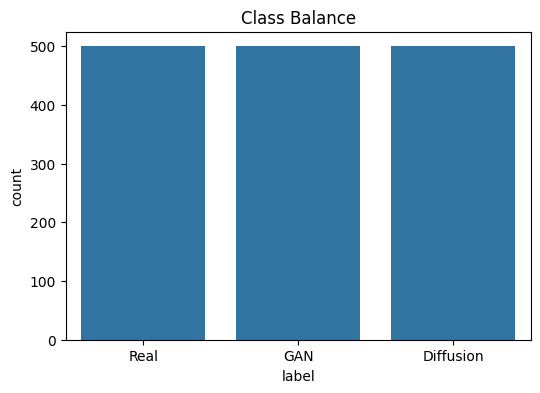

Imbalance Ratio: 1.0


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Class Balance")
plt.show()

ratio = df["label"].value_counts().max() / df["label"].value_counts().min()
print("Imbalance Ratio:", round(ratio,2))

##STATISTICAL SIGNIFICANCE

This cell applies the Kruskal-Wallis statistical test to determine whether feature distributions differ significantly across classes. It evaluates whether brightness, contrast, blur, and entropy can effectively separate real and fake images.

In [25]:
from scipy import stats

for col in ["brightness","contrast","blur","entropy"]:
    groups = [df[df["label"]==l][col] for l in df["label"].unique()]
    stat, p = stats.kruskal(*groups)
    print(f"{col} p-value = {p:.5f}")

brightness p-value = 0.00000
contrast p-value = 0.00000
blur p-value = 0.00003
entropy p-value = 0.00000


##DISTRIBUTION PLOTS

This cell visualizes feature distributions using boxplots for brightness, contrast, blur, and entropy. It helps identify visual and statistical differences between real and synthetic image classes.

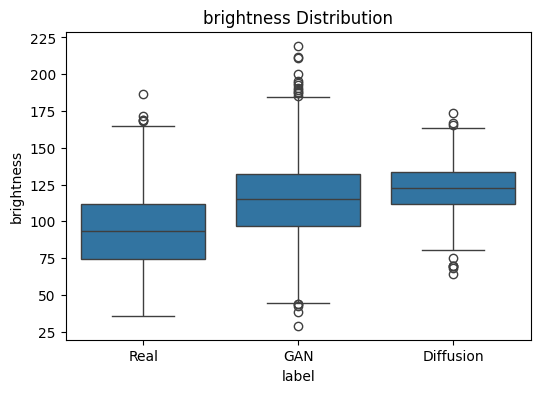

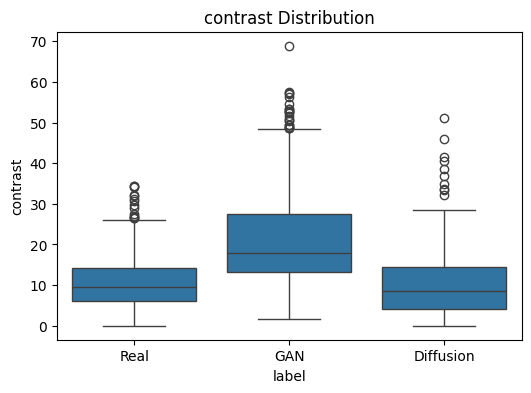

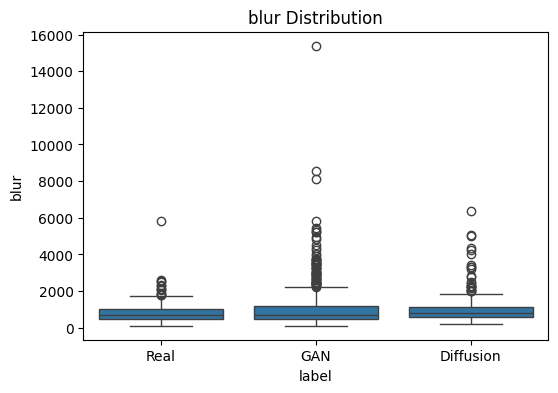

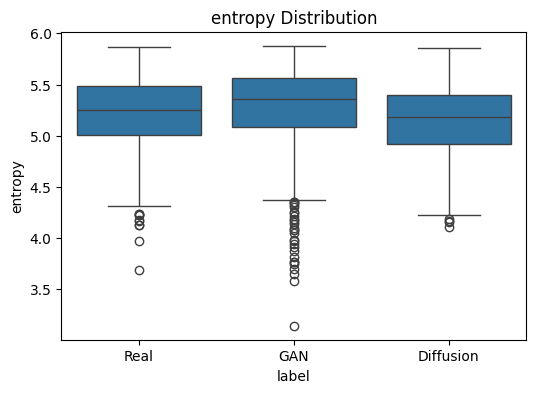

In [26]:
features = ["brightness","contrast","blur","entropy"]

for f in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="label", y=f)
    plt.title(f"{f} Distribution")
    plt.show()

##THESIS-READY INSIGHT GENERATOR

This cell converts statistical outputs into research-level insights. It interprets whether dataset features show meaningful separation or whether models may rely on artifacts instead of semantic differences.

In [27]:
print("\n===== THESIS INSIGHTS =====\n")

print("1. If blur differs → GAN detection shortcut risk")
print("2. If brightness differs → dataset bias risk")
print("3. If entropy differs → diffusion vs real separability")
print("4. If p-value < 0.05 → statistically separable features\n")

for col in ["brightness","contrast","blur","entropy"]:
    groups = [df[df["label"]==l][col] for l in df["label"].unique()]
    stat, p = stats.kruskal(*groups)

    if p < 0.05:
        print(col, ": SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION")
    else:
        print(col, ": NOT SIGNIFICANT → weak feature signal")


===== THESIS INSIGHTS =====

1. If blur differs → GAN detection shortcut risk
2. If brightness differs → dataset bias risk
3. If entropy differs → diffusion vs real separability
4. If p-value < 0.05 → statistically separable features

brightness : SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION
contrast : SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION
blur : SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION
entropy : SIGNIFICANT DIFFERENCE → GOOD FOR CLASSIFICATION


##FINAL THESIS VERDICT SCORE

This cell computes a final Dataset Readiness Score (DRS) based on balance, statistical separability, and feature consistency. It provides a quantitative measure of whether the dataset is suitable for deepfake detection model training.

In [28]:
score = 0

# balance
ratio = df["label"].value_counts().max() / df["label"].value_counts().min()
if ratio < 1.5:
    score += 25

# stats significance
for col in ["brightness","contrast","blur","entropy"]:
    groups = [df[df["label"]==l][col] for l in df["label"].unique()]
    _, p = stats.kruskal(*groups)
    if p < 0.05:
        score += 15

print("FINAL DATASET READINESS SCORE:", score, "/ 100")

if score >= 80:
    print(" EXCELLENT — READY FOR THESIS MODEL TRAINING")
elif score >= 60:
    print(" GOOD — NEED AUGMENTATION")
else:
    print(" NOT READY — DATASET WEAK")

FINAL DATASET READINESS SCORE: 85 / 100
 EXCELLENT — READY FOR THESIS MODEL TRAINING


#Initial Model Train with 5000 data from Each Datasets

###Cell : 1 Imports & Setup

In [29]:


import os, random, numpy as np, json, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image, ImageFilter
import torchvision.transforms.functional as TF
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


###Cell : 2

In [30]:
# ── Recommendation 3C: Degradation-Consistent Paired Training
# Each sample returns BOTH a clean view AND a randomly degraded view.
# Forces the network to learn forensic traces that survive real-world laundering.

def random_degrade(img_pil):
    """Apply one or more random real-world degradations."""
    ops = random.sample(["jpeg", "blur", "noise", "resize"], k=random.randint(1, 2))
    for op in ops:
        if op == "jpeg":
            from io import BytesIO
            quality = random.randint(30, 70)
            buf = BytesIO()
            img_pil.save(buf, format="JPEG", quality=quality)
            buf.seek(0)
            img_pil = Image.open(buf).convert("RGB")
        elif op == "blur":
            radius = random.uniform(0.5, 2.5)
            img_pil = img_pil.filter(ImageFilter.GaussianBlur(radius))
        elif op == "noise":
            arr = np.array(img_pil).astype(np.float32)
            noise = np.random.randn(*arr.shape) * random.uniform(5, 20)
            arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
            img_pil = Image.fromarray(arr)
        elif op == "resize":
            scale = random.uniform(0.4, 0.75)
            w, h  = img_pil.size
            small = img_pil.resize((int(w*scale), int(h*scale)), Image.BILINEAR)
            img_pil = small.resize((w, h), Image.BILINEAR)
    return img_pil


class DCPTDataset(Dataset):
    """
    Returns: (clean_tensor, degraded_tensor, real/fake label, domain_id)
    domain_id: 0 = GAN,  1 = Diffusion
    """
    def __init__(self, real_dir, fake_dir, domain_id=0,
                 base_transform=None, limit=None):
        real_imgs = [(os.path.join(real_dir, f), 0, domain_id)
                     for f in os.listdir(real_dir)
                     if f.lower().endswith(('.jpg','.png','.jpeg'))]
        fake_imgs = [(os.path.join(fake_dir, f), 1, domain_id)
                     for f in os.listdir(fake_dir)
                     if f.lower().endswith(('.jpg','.png','.jpeg'))]
        if limit:
            real_imgs = random.sample(real_imgs, min(limit, len(real_imgs)))
            fake_imgs = random.sample(fake_imgs, min(limit, len(fake_imgs)))
        self.samples       = real_imgs + fake_imgs
        random.shuffle(self.samples)
        self.base_transform = base_transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label, domain = self.samples[idx]
        try:    img = Image.open(path).convert("RGB")
        except: img = Image.new("RGB", (224, 224))
        degraded = random_degrade(img)
        if self.base_transform:
            clean_t    = self.base_transform(img)
            degraded_t = self.base_transform(degraded)
        else:
            to_t = transforms.ToTensor()
            clean_t, degraded_t = to_t(img), to_t(degraded)
        return clean_t, degraded_t, label, domain


base_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
print("DCPT Dataset class ready.")

DCPT Dataset class ready.


###Cell : 3


In [13]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles & Folders here:")
print(os.listdir())

Current Working Directory:
/content

Files & Folders here:
['.config', 'sample_data']


In [32]:
full_train_ds = DCPTDataset("real_faces_5k", "fake_gan_5k",
                             domain_id=0, base_transform=base_tf)

val_size   = int(0.2 * len(full_train_ds))
train_size = len(full_train_ds) - val_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

# Cross-generator test: diffusion domain (domain_id=1)
cross_ds     = DCPTDataset("real_faces_5k", "stable_diffusion_5k",
                            domain_id=1, base_transform=test_tf)
cross_loader = DataLoader(cross_ds, batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Cross-Gen: {len(cross_ds)}")

Train: 8000 | Val: 2000 | Cross-Gen: 10000


###Cell : 4

In [33]:
# ── Recommendation 2B: Forgery Mixup (Fo-Mixup)
# Dynamically modulates amplitude spectra in dominant frequency bands.
# Prevents the CNN from hard-coding GAN-specific spectral signatures as "fake".

def fo_mixup(imgs, alpha=0.3):
    """
    Fo-Mixup: mix amplitude spectra between two random samples in the batch.
    Operates on a batch of tensors [B, C, H, W].
    Returns augmented batch with diversified frequency content.
    """
    B = imgs.size(0)
    if B < 2:
        return imgs

    # Shuffle indices for spectral mixing partner
    idx   = torch.randperm(B, device=imgs.device)
    lam   = random.uniform(alpha, 1.0 - alpha)

    mixed = imgs.clone()
    for c in range(imgs.size(1)):       # per channel
        # FFT of original and shuffle partner
        fft_orig    = torch.fft.fft2(imgs[:, c])
        fft_partner = torch.fft.fft2(imgs[idx, c])

        # Decompose into amplitude and phase
        amp_orig    = torch.abs(fft_orig)
        phase_orig  = torch.angle(fft_orig)
        amp_partner = torch.abs(fft_partner)

        # Mix amplitudes ONLY — preserve phase (structural content)
        amp_mixed   = lam * amp_orig + (1 - lam) * amp_partner

        # Reconstruct with mixed amplitude + original phase
        fft_mixed   = amp_mixed * torch.exp(1j * phase_orig)
        mixed[:, c] = torch.fft.ifft2(fft_mixed).real

    return mixed


print("Fo-Mixup frequency debiasing ready.")

Fo-Mixup frequency debiasing ready.


###Cell : 5


In [34]:
# ── Recommendation 1A: Hybrid CNN-ViT Architecture
# CNN frontend  → extracts localized high-frequency manipulation traces
# ViT backend   → contextualizes local anomalies across global spatial domain
# This directly addresses the CNN's restricted receptive field problem.

class HybridCNNViT(nn.Module):
    """
    Stage 1 — CNN Frontend (ResNet-50 up to layer3):
        Captures local HF artifacts: GAN checkerboards, blending edges, noise.
    Stage 2 — Transformer Backend (6-head self-attention, 4 layers):
        Cross-references distant patches to detect structural/semantic impossibilities
        typical of diffusion models (mismatched reflections, geometric errors, etc.)
    """
    def __init__(self):
        super().__init__()

        # ── CNN Frontend: ResNet-50 up to layer3 → [B, 1024, 14, 14]
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.cnn_frontend = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3      # → 1024 channels
        )
        self.cnn_dim    = 1024
        self.patch_size = 14   # spatial grid after layer3 on 224px input

        # ── Patch projection: flatten spatial → token sequence
        self.patch_proj = nn.Linear(self.cnn_dim, 512)

        # ── Positional encoding
        num_patches = self.patch_size * self.patch_size   # 196 tokens
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, 512) * 0.02)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, 512) * 0.02)

        # ── Transformer Backend: 4 layers, 8 heads, dim=512
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512, nhead=8, dim_feedforward=1024,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.norm = nn.LayerNorm(512)
        self.feature_dim = 512

    def forward(self, x):
        # CNN: extract local anomaly maps
        feat_map = self.cnn_frontend(x)              # [B, 1024, 14, 14]
        B, C, H, W = feat_map.shape

        # Reshape to token sequence: [B, H*W, C]
        tokens = feat_map.flatten(2).transpose(1, 2)  # [B, 196, 1024]
        tokens = self.patch_proj(tokens)               # [B, 196, 512]

        # Prepend [CLS] token
        cls = self.cls_token.expand(B, -1, -1)         # [B, 1, 512]
        tokens = torch.cat([cls, tokens], dim=1)        # [B, 197, 512]
        tokens = tokens + self.pos_embed

        # Transformer: global cross-patch attention
        out  = self.transformer(tokens)                 # [B, 197, 512]
        out  = self.norm(out)
        feat = out[:, 0]                                # [B, 512] — CLS token
        return feat


print("Hybrid CNN-ViT backbone ready.")

Hybrid CNN-ViT backbone ready.


###Cell : 6


In [35]:
class UpgradedDeepfakeDetector(nn.Module):
    """
    Full upgraded architecture:
      ┌──────────────────────────────────────────┐
      │  Hybrid CNN-ViT Backbone → 512-dim feat  │
      └──────────┬───────────────────────────────┘
                 │
      ┌──────────┼───────────────┬──────────────┐
      ▼                          ▼               ▼
  ┌─────────┐          ┌──────────────┐   ┌────────────┐
  │ Binary  │          │Domain Discr. │   │Projection  │
  │Classif. │          │(GRL-free*)   │   │Head (128d) │
  └─────────┘          └──────────────┘   │Hard Neg.   │
                                          │Contrastive │
                                          └────────────┘

  *Domain adversarial replaced with DCPT consistency loss —
   avoids feature collapse from monolithic GRL confusion.
    """
    def __init__(self):
        super().__init__()
        self.backbone = HybridCNNViT()
        d = self.backbone.feature_dim   # 512

        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(d, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )

        # Projection head for contrastive learning (128-dim L2-normalised)
        self.proj_head = nn.Sequential(
            nn.Linear(d, 256), nn.GELU(),
            nn.Linear(256, 128)
        )

        # DCPT consistency head: projects to 64-dim for clean/degraded alignment
        self.dcpt_head = nn.Sequential(
            nn.Linear(d, 128), nn.GELU(),
            nn.Linear(128, 64)
        )

    def forward(self, x):
        feat     = self.backbone(x)
        logit    = self.classifier(feat)
        proj     = F.normalize(self.proj_head(feat), dim=1)
        dcpt_emb = self.dcpt_head(feat)
        return logit, proj, dcpt_emb, feat


print("Upgraded model architecture ready.")

Upgraded model architecture ready.


###Cell : 7


In [36]:
# ── Recommendation 3A: Cross-Category Hard Negative Mining
# Finds the HARDEST negatives in the batch (most similar real-fake pairs)
# instead of treating all cross-class pairs equally.

class HardNegativeContrastiveLoss(nn.Module):
    """
    For each anchor, selects the top-K hardest negatives
    (highest cosine similarity across opposite-class samples).
    Forces the manifold to organize around forensic authenticity,
    not low-level semantic similarity (lighting, demographics, background).
    """
    def __init__(self, temperature=0.07, hard_neg_k=5):
        super().__init__()
        self.temp = temperature
        self.k    = hard_neg_k

    def forward(self, embeddings, labels):
        B   = embeddings.size(0)
        sim = torch.matmul(embeddings, embeddings.T) / self.temp  # [B, B]
        labels = labels.view(-1, 1)

        # Same-class mask (positive pairs), exclude self
        pos_mask = (labels == labels.T).float()
        pos_mask.fill_diagonal_(0)

        # Opposite-class mask (negative pairs)
        neg_mask = (labels != labels.T).float()

        # ── Hard negative selection: for each anchor, keep top-K negatives
        neg_sim_masked = sim * neg_mask + (-1e9) * (1 - neg_mask)
        hard_k         = min(self.k, int(neg_mask.sum(dim=1).max().item()))
        hard_neg_sim, _= torch.topk(neg_sim_masked, hard_k, dim=1)   # [B, K]

        # ── Positive sim: mean over same-class pairs
        num_pos     = pos_mask.sum(dim=1).clamp(min=1)
        pos_sim     = (sim * pos_mask).sum(dim=1) / num_pos           # [B]

        # ── InfoNCE-style: log(pos / (pos + sum(hard_neg)))
        hard_neg_sum = torch.exp(hard_neg_sim).sum(dim=1)             # [B]
        pos_exp      = torch.exp(pos_sim)                             # [B]
        loss         = -torch.log(pos_exp / (pos_exp + hard_neg_sum + 1e-8))
        return loss.mean()


# ── Recommendation 3C: DCPT Loss
# KL divergence on predictions + cosine distance on features
# between clean and degraded views of the same image.

def dcpt_loss(logit_clean, logit_deg, emb_clean, emb_deg):
    """
    logit_clean / logit_deg: [B, 1] raw logits
    emb_clean   / emb_deg  : [B, 64] DCPT embeddings
    """
    p_clean = torch.sigmoid(logit_clean)
    p_deg   = torch.sigmoid(logit_deg)

    # Symmetric KL on prediction distributions
    eps = 1e-8
    kl1 = (p_clean * torch.log((p_clean + eps) / (p_deg + eps)) +
           (1-p_clean) * torch.log((1-p_clean + eps) / (1-p_deg + eps)))
    kl2 = (p_deg * torch.log((p_deg + eps) / (p_clean + eps)) +
           (1-p_deg) * torch.log((1-p_deg + eps) / (1-p_clean + eps)))
    sym_kl = (kl1 + kl2).mean()

    # Cosine distance on embeddings (encourages representation stability)
    cos_sim  = F.cosine_similarity(emb_clean, emb_deg, dim=1)
    cos_loss = (1 - cos_sim).mean()

    return sym_kl + cos_loss


bce_loss_fn     = nn.BCEWithLogitsLoss()
hard_cont_loss  = HardNegativeContrastiveLoss(temperature=0.07, hard_neg_k=5)
print("Loss functions ready.")

Loss functions ready.


###Cell : 8


In [37]:
EPOCHS  = 10
LR      = 5e-5
W_CONT  = 0.3    # hard negative contrastive weight
W_DCPT  = 0.2    # degradation consistency weight

model_v2  = UpgradedDeepfakeDetector().to(DEVICE)
optimizer = torch.optim.AdamW(model_v2.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_epoch_v2(model, loader):
    model.train()
    total_loss = 0
    lp = {"cls": 0, "cont": 0, "dcpt": 0}
    all_preds, all_labels = [], []

    for clean, degraded, labels, _ in tqdm(loader, desc="Train", leave=False):
        clean    = clean.to(DEVICE)
        degraded = degraded.to(DEVICE)
        labels   = labels.float().to(DEVICE)

        optimizer.zero_grad()

        # ── Fo-Mixup on clean batch (frequency debiasing)
        clean_mixed = fo_mixup(clean, alpha=0.25)

        # ── Forward pass: clean (Fo-Mixup'd) view
        logit_c, proj_c, dcpt_c, _ = model(clean_mixed)

        # ── Forward pass: degraded view (DCPT)
        logit_d, proj_d, dcpt_d, _ = model(degraded)

        logit_c = logit_c.squeeze(1)
        logit_d = logit_d.squeeze(1)

        # L1: Classification on clean view
        l_cls  = bce_loss_fn(logit_c, labels)

        # L2: Hard Negative Contrastive on clean projections
        l_cont = hard_cont_loss(proj_c, labels.long())

        # L3: DCPT — consistency between clean and degraded
        l_dcpt = dcpt_loss(logit_c.unsqueeze(1), logit_d.unsqueeze(1), dcpt_c, dcpt_d)

        loss = l_cls + W_CONT * l_cont + W_DCPT * l_dcpt
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss    += loss.item()
        lp["cls"]     += l_cls.item()
        lp["cont"]    += l_cont.item()
        lp["dcpt"]    += l_dcpt.item()

        preds = (torch.sigmoid(logit_c) > 0.5).long().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().long().numpy())

    n   = len(loader)
    acc = accuracy_score(all_labels, all_preds)
    return total_loss/n, {k: v/n for k,v in lp.items()}, acc


def eval_v2(model, loader, desc="Val"):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for clean, _, labels, _ in tqdm(loader, desc=desc, leave=False):
            clean = clean.to(DEVICE)
            logit, _, _, _ = model(clean)
            probs = torch.sigmoid(logit.squeeze(1)).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    preds = (np.array(all_probs) > 0.5).astype(int)
    acc   = accuracy_score(all_labels, preds)
    auc   = roc_auc_score(all_labels, all_probs)
    return acc, auc, all_labels, all_probs


# ══ RUN ══
print("="*65)
print("  TRAINING: Upgraded Model v2 (CNN-ViT + Fo-Mixup + HardNeg + DCPT)")
print("="*65)

history_v2 = {"train_loss":[], "train_acc":[], "val_acc":[], "val_auc":[],
               "l_cls":[], "l_cont":[], "l_dcpt":[]}
best_auc_v2 = 0.0

for epoch in range(1, EPOCHS+1):
    t_loss, lp, t_acc    = train_epoch_v2(model_v2, train_loader)
    v_acc, v_auc, _, _   = eval_v2(model_v2, val_loader, "Val")
    scheduler.step()

    history_v2["train_loss"].append(t_loss)
    history_v2["train_acc"].append(t_acc)
    history_v2["val_acc"].append(v_acc)
    history_v2["val_auc"].append(v_auc)
    history_v2["l_cls"].append(lp["cls"])
    history_v2["l_cont"].append(lp["cont"])
    history_v2["l_dcpt"].append(lp["dcpt"])

    if v_auc > best_auc_v2:
        best_auc_v2 = v_auc
        torch.save(model_v2.state_dict(), "upgraded_model_v2_best.pth")

    print(f"Epoch {epoch:2d}/{EPOCHS}  Loss={t_loss:.4f}  "
          f"[cls={lp['cls']:.3f} cont={lp['cont']:.3f} dcpt={lp['dcpt']:.3f}]  "
          f"Val Acc={v_acc:.4f}  Val AUC={v_auc:.4f}")

print(f"\nBest Val AUC: {best_auc_v2:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]
/tmp/ipykernel_3750/1000143655.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)


  TRAINING: Upgraded Model v2 (CNN-ViT + Fo-Mixup + HardNeg + DCPT)


Epoch  1/10  Loss=0.0905  [cls=0.050 cont=0.097 dcpt=0.056]  Val Acc=1.0000  Val AUC=1.0000


Epoch  2/10  Loss=0.0118  [cls=0.004 cont=0.010 dcpt=0.021]  Val Acc=1.0000  Val AUC=1.0000


...

Epoch  6/10  Loss=0.0037  [cls=0.002 cont=0.004 dcpt=0.005]  Val Acc=1.0000  Val AUC=1.0000


Epoch  7/10  Loss=0.0032  [cls=0.002 cont=0.003 dcpt=0.003]  Val Acc=1.0000  Val AUC=1.0000


Epoch  8/10  Loss=0.0017  [cls=0.000 cont=0.000 dcpt=0.006]  Val Acc=1.0000  Val AUC=1.0000


Epoch  9/10  Loss=0.0008  [cls=0.000 cont=0.000 dcpt=0.004]  Val Acc=1.0000  Val AUC=1.0000


Epoch 10/10  Loss=0.0002  [cls=0.000 cont=0.000 dcpt=0.001]  Val Acc=1.0000  Val AUC=1.0000

Best Val AUC: 1.0000


###Cell : 9


In [38]:
# ── Recommendation: Cross-AUC Metric
# Standard AUC hides score-shifting across domains.
# Cross-AUC evaluates: real(domain_A) vs fake(domain_B)
# and:                  real(domain_B) vs fake(domain_A)
# This exposes true zero-shot generalization.

model_v2.load_state_dict(torch.load("upgraded_model_v2_best.pth"))

def collect_by_class(model, loader):
    """Returns separate prob lists for real and fake samples."""
    model.eval()
    real_probs, fake_probs = [], []
    with torch.no_grad():
        for clean, _, labels, _ in tqdm(loader, desc="Collecting", leave=False):
            clean = clean.to(DEVICE)
            logit, _, _, _ = model(clean)
            probs = torch.sigmoid(logit.squeeze(1)).cpu().numpy()
            for p, l in zip(probs, labels.numpy()):
                (real_probs if l == 0 else fake_probs).append(p)
    return real_probs, fake_probs

# Collect from both domains
val_real,   val_fake   = collect_by_class(model_v2, val_loader)
cross_real, cross_fake = collect_by_class(model_v2, cross_loader)

def cross_auc(real_probs_A, fake_probs_B):
    """AUC where real samples from domain A vs fake samples from domain B."""
    labels = [0]*len(real_probs_A) + [1]*len(fake_probs_B)
    scores = list(real_probs_A)    + list(fake_probs_B)
    return roc_auc_score(labels, scores)

# Standard intra-domain AUC
val_acc,   val_auc,   vl, vp   = eval_v2(model_v2, val_loader,   "Val GAN")
cross_acc, cross_auc_std, cl, cp = eval_v2(model_v2, cross_loader, "Cross-Gen")

# Cross-AUC pairs (the metric standard AUC hides)
cauc_A = cross_auc(val_real,   cross_fake)   # real(GAN domain)  vs fake(Diffusion)
cauc_B = cross_auc(cross_real, val_fake)     # real(Diff domain) vs fake(GAN)
mean_cross_auc = (cauc_A + cauc_B) / 2

print("\n" + "="*65)
print("  CROSS-AUC EVALUATION RESULTS")
print("="*65)
print(f"  Standard Same-Gen Val AUC          : {val_auc:.4f}")
print(f"  Standard Cross-Gen Test AUC        : {cross_auc_std:.4f}")
print(f"  Cross-AUC  (real_GAN  vs fake_Diff): {cauc_A:.4f}")
print(f"  Cross-AUC  (real_Diff vs fake_GAN) : {cauc_B:.4f}")
print(f"  Mean Cross-AUC                     : {mean_cross_auc:.4f}")
print(f"\n  AUC Generalization Drop            : {val_auc - cross_auc_std:.4f}")
print("\n  Classification Report (Cross-Generator):")
print(classification_report(cl, (np.array(cp)>0.5).astype(int),
                             target_names=["Real","Fake"]))


  CROSS-AUC EVALUATION RESULTS
  Standard Same-Gen Val AUC          : 1.0000
  Standard Cross-Gen Test AUC        : 0.9996
  Cross-AUC  (real_GAN  vs fake_Diff): 0.9993
  Cross-AUC  (real_Diff vs fake_GAN) : 1.0000
  Mean Cross-AUC                     : 0.9997

  AUC Generalization Drop            : 0.0004

  Classification Report (Cross-Generator):
              precision    recall  f1-score   support

        Real       0.63      1.00      0.77      5000
        Fake       1.00      0.41      0.58      5000

    accuracy                           0.71     10000
   macro avg       0.81      0.71      0.68     10000
weighted avg       0.81      0.71      0.68     10000



###Cell : 10


In [1]:
# ── Robustness Evaluation (NTIRE 2026 style)
# Test model on progressively degraded versions of cross-gen set.

def robust_eval(model, base_loader, jpeg_quality):
    """Re-evaluate cross_ds with forced JPEG compression at given quality."""
    model.eval()
    all_probs, all_labels = [], []
    norm = transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    to_t = transforms.ToTensor()
    resize = transforms.Resize((224, 224))

    with torch.no_grad():
        for clean, _, labels, _ in base_loader:
            # Re-degrade: apply fixed JPEG quality
            batch_imgs = []
            for i in range(clean.size(0)):
                # Un-normalize to PIL
                img_t = clean[i].cpu()
                mean  = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
                std   = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
                img_t = (img_t * std + mean).clamp(0, 1)
                img_p = TF.to_pil_image(img_t)
                from io import BytesIO
                buf = BytesIO()
                img_p.save(buf, "JPEG", quality=jpeg_quality)
                buf.seek(0)
                img_p = Image.open(buf).convert("RGB")
                batch_imgs.append(norm(to_t(resize(img_p))))
            batch_t = torch.stack(batch_imgs).to(DEVICE)
            logit, _, _, _ = model(batch_t)
            probs = torch.sigmoid(logit.squeeze(1)).cpu().numpy()
            all_probs.extend(probs); all_labels.extend(labels.numpy())

    return roc_auc_score(all_labels, all_probs)

print("Running robustness sweep (JPEG quality: 80 → 20)...")
qualities = [80, 60, 40, 20]
robust_aucs = {}
for q in qualities:
    auc_r = robust_eval(model_v2, cross_loader, jpeg_quality=q)
    robust_aucs[q] = round(auc_r, 4)
    print(f"  JPEG Quality {q:3d} → Robust AUC: {auc_r:.4f}")


# ── Load all previous results for comparison
try:
    with open("baseline_benchmark_results.json") as f:
        b = json.load(f)
    b_same, b_cross, b_drop = b["same_gen_val_auc"], b["cross_gen_test_auc"], b["auc_drop"]
except: b_same=b_cross=b_drop=None

try:
    with open("thesis_model_results.json") as f:
        t = json.load(f)
    t_same, t_cross, t_drop = t["same_gen_val_auc"], t["cross_gen_test_auc"], t["auc_drop"]
except: t_same=t_cross=t_drop=None

v2_drop = round(val_auc - cross_auc_std, 4)

print("\n" + "="*68)
print("  FINAL COMPARISON: Baseline vs Thesis v1 vs Upgraded v2")
print("="*68)
print(f"  {'Metric':<32} {'Baseline':>10} {'Thesis v1':>11} {'Upgraded v2':>13}")
print(f"  {'-'*66}")
if b_same:
    print(f"  {'Same-Gen Val AUC':<32} {b_same:>10.4f} {t_same:>11.4f} {val_auc:>13.4f}")
    print(f"  {'Cross-Gen Test AUC':<32} {b_cross:>10.4f} {t_cross:>11.4f} {cross_auc_std:>13.4f}")
    print(f"  {'AUC Drop (↓ better)':<32} {b_drop:>10.4f} {t_drop:>11.4f} {v2_drop:>13.4f}")
print(f"  {'Mean Cross-AUC':<32} {'N/A':>10} {'N/A':>11} {mean_cross_auc:>13.4f}")
for q, auc_r in robust_aucs.items():
    print(f"  {f'Robust AUC (JPEG q={q})':<32} {'N/A':>10} {'N/A':>11} {auc_r:>13.4f}")


# Save v2 results
results_v2 = {
    "model": "Upgraded v2: CNN-ViT + Fo-Mixup + HardNeg Contrastive + DCPT",
    "same_gen_val_auc":   round(val_auc, 4),
    "cross_gen_test_auc": round(cross_auc_std, 4),
    "mean_cross_auc":     round(mean_cross_auc, 4),
    "auc_drop":           v2_drop,
    "robust_auc_by_jpeg": robust_aucs,
    "training_history":   history_v2
}
with open("upgraded_v2_results.json", "w") as f:
    json.dump(results_v2, f, indent=2)
print("\nResults saved → upgraded_v2_results.json")

Running robustness sweep (JPEG quality: 80 → 20)...


NameError: name 'model_v2' is not defined

###Cell : 11


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ep = range(1, EPOCHS+1)

# 1 — Val AUC over epochs
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ep, history_v2["val_auc"], 'b-o', label="Upgraded v2")
ax1.axhline(cross_auc_std, color='r', ls='--', label=f"Cross-Gen={cross_auc_std:.3f}")
ax1.set_title("Validation AUC (v2)"); ax1.set_xlabel("Epoch")
ax1.legend(fontsize=8); ax1.grid(True)

# 2 — Loss decomposition
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ep, history_v2["l_cls"],  label="Classification")
ax2.plot(ep, history_v2["l_cont"], label="Hard-Neg Contrastive")
ax2.plot(ep, history_v2["l_dcpt"], label="DCPT")
ax2.set_title("Loss Components"); ax2.set_xlabel("Epoch")
ax2.legend(fontsize=8); ax2.grid(True)

# 3 — AUC Drop comparison (3 models)
ax3 = fig.add_subplot(gs[0, 2])
if b_same:
    names  = ["Baseline\nResNet-50", "Thesis v1\n+DAL+Cont", "Upgraded v2\n+ViT+Fo-Mixup\n+HardNeg+DCPT"]
    drops  = [b_drop, t_drop, v2_drop]
    colors = ['#e74c3c', '#f39c12', '#2ecc71']
    bars   = ax3.bar(names, drops, color=colors, width=0.5)
    ax3.set_title("Generalization Gap\n(AUC Drop ↓ Better)")
    ax3.set_ylabel("Same-Gen AUC − Cross-Gen AUC")
    for bar, val in zip(bars, drops):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{val:.4f}", ha='center', fontweight='bold', fontsize=9)
    ax3.grid(axis='y')

# 4 — Cross-AUC breakdown
ax4 = fig.add_subplot(gs[1, 0])
labels_auc = ["Same-Gen\nVal AUC", "Cross-Gen\nAUC", "Cross-AUC\nA→B", "Cross-AUC\nB→A", "Mean\nCross-AUC"]
vals_auc   = [val_auc, cross_auc_std, cauc_A, cauc_B, mean_cross_auc]
colors4    = ['#3498db','#e74c3c','#9b59b6','#9b59b6','#1abc9c']
ax4.bar(labels_auc, vals_auc, color=colors4, width=0.5)
ax4.set_title("Cross-AUC Protocol"); ax4.set_ylabel("AUC")
ax4.set_ylim(0.4, 1.05); ax4.grid(axis='y')
for i, v in enumerate(vals_auc):
    ax4.text(i, v+0.005, f"{v:.3f}", ha='center', fontsize=8, fontweight='bold')

# 5 — Robustness (Robust AUC vs JPEG quality)
ax5 = fig.add_subplot(gs[1, 1])
qs   = list(robust_aucs.keys())
aucs = list(robust_aucs.values())
ax5.plot(qs, aucs, 'g-s', markersize=8)
ax5.set_title("Robust AUC vs JPEG Quality\n(NTIRE 2026 Style)")
ax5.set_xlabel("JPEG Quality (lower = more degraded)")
ax5.set_ylabel("AUC"); ax5.invert_xaxis()
ax5.set_ylim(0.4, 1.05); ax5.grid(True)
for q, a in zip(qs, aucs):
    ax5.annotate(f"{a:.3f}", (q, a), textcoords="offset points", xytext=(0,8),
                 ha='center', fontsize=8)

# 6 — Architecture comparison table
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
table_data = [
    ["Component",          "Baseline", "v1",  "v2 (Ours)"],
    ["Backbone",           "ResNet-50","ResNet-50","CNN+ViT"],
    ["Freq. Debiasing",    "✗",        "✗",   "Fo-Mixup ✓"],
    ["Domain Adaptation",  "✗",        "GRL", "DCPT ✓"],
    ["Contrastive Loss",   "✗",        "Basic","Hard-Neg ✓"],
    ["Cross-AUC Metric",   "✗",        "✗",   "✓"],
    ["Robustness Test",    "✗",        "✗",   "✓"],
]
tbl = ax6.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center',
                colWidths=[0.38, 0.18, 0.12, 0.22])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
tbl.scale(1, 1.5)
ax6.set_title("Architecture Comparison", pad=12)

plt.suptitle("Upgraded Deepfake Detection v2 — SOTA-Aligned Results",
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig("upgraded_v2_results_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → upgraded_v2_results_plot.png")